# Chapter 03. 데이터의 첫인상 읽기 — 실행 완료 제출본

제공된 `notebooks/ch03_data_overview.ipynb`의 실습을 실행하고, 뒤에 제출 답안과 추가 검증을 작성했다. 원본 CSV는 변경하지 않는다. 고객 이름은 출력에서 마스킹한다. 증빙 PNG는 실제 실행 결과를 표로 렌더링한 것이며 화면 캡처는 아니다.

## 0. 이번 장에서 확인할 것

데이터를 처음 열었을 때는 다음 질문에 답할 수 있어야 합니다.

- 데이터 파일은 몇 개인가?
- 각 파일은 어떤 역할을 하는가?
- 각 파일은 몇 행, 몇 열로 구성되어 있는가?
- 어떤 컬럼이 있고, 각 컬럼은 어떤 의미를 가지는가?
- 숫자, 문자, 날짜 컬럼은 무엇인가?
- 비어 있는 값이나 중복된 값은 없는가?
- 여러 파일을 연결할 수 있는 기준 컬럼은 무엇인가?
- LLM이 설명한 데이터 구조가 실제 데이터와 일치하는가?


CSV 파일은 텍스트 파일이지만, pandas로 불러오면 행과 열을 가진 `DataFrame`으로 다룰 수 있습니다.


## 1. 실습 준비

먼저 필요한 패키지를 불러오고, 프로젝트 폴더와 데이터 폴더를 찾습니다. 노트북을 `notebooks` 폴더에서 실행해도 되고, 프로젝트 루트에서 실행해도 되도록 `find_project_root()` 함수를 사용합니다.


In [1]:
from pathlib import Path

import pandas as pd

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)


def find_project_root(start: Path) -> Path:
    """현재 위치에서 위로 올라가며 data/raw 폴더가 있는 프로젝트 루트를 찾습니다."""
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "data" / "raw").exists() and (candidate / "book").exists():
            return candidate
    raise FileNotFoundError("프로젝트 루트를 찾지 못했습니다. 노트북을 저장소 안에서 실행해 주세요.")


PROJECT_ROOT = find_project_root(Path.cwd())
DATA_DIR = PROJECT_ROOT / "data" / "raw"

print("프로젝트 루트:", PROJECT_ROOT)
print("데이터 폴더:", DATA_DIR)

from IPython.display import display
import sys
print("Python:", sys.version.split()[0], "pandas:", pd.__version__)

프로젝트 루트: /Users/kjj/MyLLMGit/llm-data-analysis-study
데이터 폴더: /Users/kjj/MyLLMGit/llm-data-analysis-study/data/raw
Python: 3.12.0 pandas: 3.0.5


### 결과 관찰
처음 cell을 실행했을 때 FileNotFoundError 가 발생하였음

### 나의 해석과 판단
코드와 에러 로그를 분석해보니 data/raw 디렉토리는 있으나 book 디렉토리가 없어서 (candidate / "book").exists() 에서 실패하여 FileNotFoundError가 발생한 것을 확인하여 book 디렉토리를 추가하여 에러를 수정하였음

### 업무·분석적 의미
데이터 분석 과정에서 코드 자체의 문제뿐만 아니라 사전에 요구되는 디렉토리 및 파일 구조가 정상적으로 구성되어 있는지 확인하는 과정이 중요함을 확인함

### 한계와 추가 확인 사항
현재는 book 디렉토리를 추가하여 오류가 해결되었으나, 이후 분석 과정에서 해당 디렉토리 내부에 필요한 파일이 정상적으로 존재하는지와 데이터가 올바르게 로드되는지 추가 확인이 필요함

## 2. 데이터 파일이 있는지 확인하기

파일 경로 오류는 초보자가 가장 자주 만나는 오류입니다. 데이터를 불러오기 전에 필요한 CSV 파일이 실제로 있는지 먼저 확인합니다.


In [2]:
expected_files = [
    "customers.csv",
    "products.csv",
    "orders.csv",
    "order_items.csv",
]

file_check = pd.DataFrame({
    "file": expected_files,
    "path": [str(DATA_DIR / filename) for filename in expected_files],
    "exists": [(DATA_DIR / filename).exists() for filename in expected_files],
})

file_check


,file,path,exists
0,customers.csv,/Users/kjj/MyLLMGit/llm-data-analysis-study/da...,True
1,products.csv,/Users/kjj/MyLLMGit/llm-data-analysis-study/da...,True
2,orders.csv,/Users/kjj/MyLLMGit/llm-data-analysis-study/da...,True
3,order_items.csv,/Users/kjj/MyLLMGit/llm-data-analysis-study/da...,True


`exists`가 모두 `True`이면 다음 단계로 진행할 수 있습니다.

하나라도 `False`라면 데이터가 아직 생성되지 않았을 수 있습니다. 그 경우 터미널에서 아래 명령을 실행해 샘플 데이터를 생성합니다.

```bash
python scripts/generate_sample_data.py
```


## 3. CSV 파일을 DataFrame으로 불러오기

이제 4개의 CSV 파일을 pandas `DataFrame`으로 불러옵니다. 각 변수 이름은 파일 이름과 비슷하게 맞춰 두면 이후 코드를 읽기 쉽습니다.


In [3]:
customers = pd.read_csv(DATA_DIR / "customers.csv")
products = pd.read_csv(DATA_DIR / "products.csv")
orders = pd.read_csv(DATA_DIR / "orders.csv")
order_items = pd.read_csv(DATA_DIR / "order_items.csv")

print("customers:", type(customers))
print("products:", type(products))
print("orders:", type(orders))
print("order_items:", type(order_items))


customers: <class 'pandas.DataFrame'>
products: <class 'pandas.DataFrame'>
orders: <class 'pandas.DataFrame'>
order_items: <class 'pandas.DataFrame'>


분석할 데이터셋이 여러 개일 때는 딕셔너리로 묶어 두면 반복 점검을 하기 편합니다.


In [4]:
datasets = {
    "customers": customers,
    "products": products,
    "orders": orders,
    "order_items": order_items,
}

list(datasets.keys())


['customers', 'products', 'orders', 'order_items']

## 4. 각 파일의 역할 이해하기

이번 과정에서 사용하는 데이터는 가상의 온라인 쇼핑몰 운영 데이터입니다.

| 파일 | 역할 | 먼저 확인할 것 |
| --- | --- | --- |
| `customers.csv` | 고객 정보 | 고객 수, 연령, 성별, 지역, 가입일 |
| `products.csv` | 상품 정보 | 상품 수, 카테고리, 가격 |
| `orders.csv` | 주문 정보 | 주문 수, 주문일, 결제수단, 주문상태 |
| `order_items.csv` | 주문 상세 정보 | 주문별 상품, 수량, 단가 |

처음에는 파일을 합치지 말고, 각 파일을 따로 살펴보는 것이 좋습니다.


DataFrame은 행(row)과 열(column)로 구성됩니다. `shape`, `head()`, `columns`, `info()` 같은 기본 도구를 사용해 구조를 확인합니다.


## 5. 데이터 크기 확인하기

`shape`는 데이터의 행과 열 개수를 알려 줍니다.

- 앞 숫자: 행 개수
- 뒤 숫자: 열 개수

예를 들어 `(150, 6)`은 150행 6열이라는 뜻입니다.


In [5]:
print("customers:", customers.shape)
print("products:", products.shape)
print("orders:", orders.shape)
print("order_items:", order_items.shape)


customers: (150, 6)
products: (100, 4)
orders: (300, 5)
order_items: (764, 5)


In [6]:
shape_summary = pd.DataFrame([
    {
        "dataset": name,
        "rows": df.shape[0],
        "columns": df.shape[1],
    }
    for name, df in datasets.items()
])

shape_summary


,dataset,rows,columns
0,customers,150,6
1,products,100,4
2,orders,300,5
3,order_items,764,5


### 생각해 보기

- 가장 행이 많은 데이터셋은 무엇인가요?
- `order_items`가 `orders`보다 행이 많다면, 그 이유는 무엇일까요?
- 분석 보고서에 데이터 규모를 설명한다면 어떤 문장으로 쓸 수 있을까요?


## 6. 데이터 앞부분과 마지막 부분 보기

`head()`는 앞부분 5행을 보여 줍니다. 컬럼명이 예상과 맞는지, 값의 형태가 자연스러운지 빠르게 확인할 때 사용합니다.


In [7]:
customers.head().assign(name="[마스킹]")

,customer_id,name,gender,age,city,signup_date
0,1,[마스킹],F,19,광주,2024-05-17
1,2,[마스킹],F,32,대구,2023-12-20
2,3,[마스킹],F,61,성남,2025-03-22
3,4,[마스킹],F,55,울산,2025-05-05
4,5,[마스킹],F,19,부산,2023-09-23


In [8]:
products.head()


,product_id,product_name,category,price
0,1,전자기기 상품 001,전자기기,160000
1,2,도서 상품 002,도서,34000
2,3,전자기기 상품 003,전자기기,152000
3,4,생활용품 상품 004,생활용품,70000
4,5,식품 상품 005,식품,186000


In [9]:
orders.head()


,order_id,customer_id,order_date,payment_method,order_status
0,1,123,2025-10-16,card,completed
1,2,77,2026-06-05,naver_pay,cancelled
2,3,138,2026-03-12,bank_transfer,cancelled
3,4,57,2026-06-19,kakao_pay,cancelled
4,5,125,2026-05-25,card,cancelled


In [10]:
order_items.head()


,order_item_id,order_id,product_id,quantity,unit_price
0,1,1,100,3,102000
1,2,1,87,5,25000
2,3,1,7,3,142000
3,4,1,9,3,193000
4,5,2,72,4,189000


앞부분만 보고 전체 데이터가 정상이라고 판단하기는 어렵습니다. `tail()`로 마지막 부분도 확인해 봅니다.


In [11]:
for name, df in datasets.items():
    print(name, "tail")
    display(df.tail().assign(name="[마스킹]") if name == "customers" else df.tail())

customers tail


,customer_id,name,gender,age,city,signup_date
145,146,[마스킹],M,61,성남,2023-12-19
146,147,[마스킹],M,19,부산,2025-07-15
147,148,[마스킹],M,29,고양,2024-04-02
148,149,[마스킹],M,20,부산,2026-05-07
149,150,[마스킹],M,40,대전,2026-07-21


products tail


,product_id,product_name,category,price
95,96,생활용품 상품 096,생활용품,112000
96,97,전자기기 상품 097,전자기기,154000
97,98,스포츠 상품 098,스포츠,10000
98,99,뷰티 상품 099,뷰티,200000
99,100,도서 상품 100,도서,102000


orders tail


,order_id,customer_id,order_date,payment_method,order_status
295,296,116,2026-02-02,card,completed
296,297,22,2026-03-10,bank_transfer,completed
297,298,64,2025-12-10,naver_pay,cancelled
298,299,135,2026-04-12,bank_transfer,completed
299,300,96,2026-04-13,kakao_pay,cancelled


order_items tail


,order_item_id,order_id,product_id,quantity,unit_price
759,760,297,42,4,28000
760,761,298,40,4,174000
761,762,299,8,2,189000
762,763,299,12,4,175000
763,764,300,59,5,32000


### 생각해 보기

`head()`와 `tail()`을 보면서 아래를 확인해 보세요.

- 날짜처럼 보이는 컬럼이 있나요?
- 숫자처럼 보이는 컬럼이 있나요?
- ID처럼 보이는 컬럼이 있나요?
- 사람이 직접 읽을 수 있는 이름이나 범주 값이 있나요?


## 7. 컬럼명 확인하기

컬럼명은 코드 작성에서 매우 중요합니다. 실제 컬럼명이 `customer_id`인데 LLM이나 사람이 `cust_id`라고 쓰면 코드는 실행되지 않습니다.


In [12]:
for name, df in datasets.items():
    print(f"[{name}]")
    print(list(df.columns))
    print()


[customers]
['customer_id', 'name', 'gender', 'age', 'city', 'signup_date']

[products]
['product_id', 'product_name', 'category', 'price']

[orders]
['order_id', 'customer_id', 'order_date', 'payment_method', 'order_status']

[order_items]
['order_item_id', 'order_id', 'product_id', 'quantity', 'unit_price']



In [13]:
column_summary = pd.DataFrame([
    {
        "dataset": name,
        "column_count": len(df.columns),
        "column_names": ", ".join(df.columns),
    }
    for name, df in datasets.items()
])

column_summary


,dataset,column_count,column_names
0,customers,6,"customer_id, name, gender, age, city, signup_date"
1,products,4,"product_id, product_name, category, price"
2,orders,5,"order_id, customer_id, order_date, payment_met..."
3,order_items,5,"order_item_id, order_id, product_id, quantity,..."


### 생각해 보기

- 고객을 구분하는 컬럼은 무엇인가요?
- 주문을 구분하는 컬럼은 무엇인가요?
- 상품을 구분하는 컬럼은 무엇인가요?
- 여러 파일을 연결할 때 사용할 수 있을 것 같은 컬럼은 무엇인가요?


## 8. 데이터 타입 확인하기

`info()`는 컬럼별 데이터 타입과 비어 있지 않은 값의 개수를 보여 줍니다.

특히 날짜처럼 보이지만 `object`로 저장된 컬럼을 주의해서 봅니다. pandas에서 `object`는 보통 문자열 또는 여러 타입이 섞인 컬럼일 때 나타납니다.


In [14]:
customers.info()


<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   customer_id  150 non-null    int64
 1   name         150 non-null    str  
 2   gender       150 non-null    str  
 3   age          150 non-null    int64
 4   city         150 non-null    str  
 5   signup_date  150 non-null    str  
dtypes: int64(2), str(4)
memory usage: 11.0 KB


In [15]:
for name, df in datasets.items():
    print(f"\n===== {name} =====")
    df.info()



===== customers =====
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   customer_id  150 non-null    int64
 1   name         150 non-null    str  
 2   gender       150 non-null    str  
 3   age          150 non-null    int64
 4   city         150 non-null    str  
 5   signup_date  150 non-null    str  
dtypes: int64(2), str(4)
memory usage: 11.0 KB

===== products =====
<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   product_id    100 non-null    int64
 1   product_name  100 non-null    str  
 2   category      100 non-null    str  
 3   price         100 non-null    int64
dtypes: int64(2), str(2)
memory usage: 6.0 KB

===== orders =====
<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 5 columns)

In [16]:
dtype_summary = pd.concat(
    [df.dtypes.rename(name) for name, df in datasets.items()],
    axis=1,
).fillna("")

dtype_summary


,customers,products,orders,order_items
customer_id,int64,,int64,
name,str,,,
gender,str,,,
age,int64,,,
city,str,,,
signup_date,str,,,
product_id,,int64,,int64
product_name,,str,,
category,,str,,
price,,int64,,


### 생각해 보기

- 숫자형 컬럼은 어떤 것들이 있나요?
- 문자형 컬럼은 어떤 것들이 있나요?
- 날짜처럼 보이지만 아직 문자열일 가능성이 있는 컬럼은 무엇인가요?


데이터 구조 점검은 파일 확인, 로드, 크기 확인, 컬럼 확인, 타입 확인, 결측치 확인, 중복 확인, 키 관계 확인 순서로 진행하면 좋습니다.


## 9. 결측치 확인하기

결측치는 값이 비어 있는 상태입니다. 결측치가 있으면 평균, 비율, 그룹별 집계 결과가 달라질 수 있습니다.

`isna().sum()`은 컬럼별 결측치 개수를 계산합니다.


In [17]:
customers.isna().sum()


customer_id    0
name           0
gender         0
age            0
city           0
signup_date    0
dtype: int64

In [18]:
missing_summary = pd.concat(
    [df.isna().sum().rename(name) for name, df in datasets.items()],
    axis=1,
).fillna("").astype(str)

missing_summary


,customers,products,orders,order_items
customer_id,0.0,,0.0,
name,0.0,,,
gender,0.0,,,
age,0.0,,,
city,0.0,,,
signup_date,0.0,,,
product_id,,0.0,,0.0
product_name,,0.0,,
category,,0.0,,
price,,0.0,,


In [19]:
missing_rate_summary = pd.concat(
    [(df.isna().mean() * 100).round(2).rename(name) for name, df in datasets.items()],
    axis=1,
).fillna("")

missing_rate_summary


,customers,products,orders,order_items
customer_id,0.0,,0.0,
name,0.0,,,
gender,0.0,,,
age,0.0,,,
city,0.0,,,
signup_date,0.0,,,
product_id,,0.0,,0.0
product_name,,0.0,,
category,,0.0,,
price,,0.0,,


### 결측치 해석 팁

결측치가 있다고 해서 무조건 삭제하는 것은 아닙니다.

| 처리 방법 | 설명 |
| --- | --- |
| 행 제외 | 결측치가 있는 행을 분석에서 제외합니다. |
| 대표값 대체 | 평균, 중앙값, 최빈값 등으로 채웁니다. |
| 별도 범주 처리 | `Unknown` 같은 범주로 표시합니다. |
| 컬럼 제외 | 분석 목적에 맞지 않는 컬럼은 사용하지 않습니다. |
| 원인 확인 | 수집 과정에서 문제가 있었는지 확인합니다. |


## 10. 중복 데이터 확인하기

중복은 같은 행이나 같은 ID가 반복되는 상태입니다.

단, 모든 중복이 오류는 아닙니다. 예를 들어 `order_items`에서는 한 주문에 여러 상품이 들어갈 수 있으므로 같은 `order_id`가 여러 번 나올 수 있습니다.


In [20]:
duplicate_rows = pd.DataFrame([
    {
        "dataset": name,
        "duplicated_rows": df.duplicated().sum(),
    }
    for name, df in datasets.items()
])

duplicate_rows


,dataset,duplicated_rows
0,customers,0
1,products,0
2,orders,0
3,order_items,0


In [21]:
id_duplicate_checks = pd.DataFrame([
    {
        "check": "customers.customer_id",
        "duplicated_count": customers["customer_id"].duplicated().sum(),
        "interpretation": "0이어야 고객 ID가 유일합니다.",
    },
    {
        "check": "products.product_id",
        "duplicated_count": products["product_id"].duplicated().sum(),
        "interpretation": "0이어야 상품 ID가 유일합니다.",
    },
    {
        "check": "orders.order_id",
        "duplicated_count": orders["order_id"].duplicated().sum(),
        "interpretation": "0이어야 주문 ID가 유일합니다.",
    },
    {
        "check": "order_items.order_id",
        "duplicated_count": order_items["order_id"].duplicated().sum(),
        "interpretation": "한 주문에 여러 상품이 있으면 0보다 클 수 있습니다.",
    },
])

id_duplicate_checks


,check,duplicated_count,interpretation
0,customers.customer_id,0,0이어야 고객 ID가 유일합니다.
1,products.product_id,0,0이어야 상품 ID가 유일합니다.
2,orders.order_id,0,0이어야 주문 ID가 유일합니다.
3,order_items.order_id,464,한 주문에 여러 상품이 있으면 0보다 클 수 있습니다.


### 생각해 보기

- `customers.customer_id` 중복과 `order_items.order_id` 중복은 왜 의미가 다를까요?
- 중복 개수만 보고 삭제하면 위험한 이유는 무엇일까요?


## 11. 숫자형 컬럼 기본 통계 확인하기

`describe()`는 숫자형 컬럼의 개수, 평균, 표준편차, 최솟값, 사분위수, 최댓값을 보여 줍니다.

최솟값이나 최댓값이 지나치게 이상하면 데이터 오류나 이상치 가능성을 의심할 수 있습니다.


In [22]:
customers[["age"]].describe()  # ID는 측정값이 아니므로 통계에서 제외

,age
count,150.000000
mean,42.086667
std,15.613166
min,19.000000
25%,29.000000
50%,40.000000
75%,57.000000
max,69.000000


In [23]:
products[["price"]].describe()


,price
count,100.000000
mean,110040.000000
std,56433.910574
min,5000.000000
25%,65750.000000
50%,112000.000000
75%,161000.000000
max,200000.000000


In [24]:
order_items[["quantity", "unit_price"]].describe()


,quantity,unit_price
count,764.000000,764.000000
mean,3.053665,108561.518325
std,1.410873,56996.770604
min,1.000000,5000.000000
25%,2.000000,62000.000000
50%,3.000000,111000.000000
75%,4.000000,161250.000000
max,5.000000,200000.000000


숫자가 문자열로 저장된 경우도 있습니다. 예를 들어 `"10,000"`처럼 쉼표가 포함된 문자열은 바로 계산하기 어렵습니다.


In [25]:
price_text = pd.Series(["10,000", "25,500", "3000", "확인필요"])
price_number = pd.to_numeric(
    price_text.str.replace(",", "", regex=False),
    errors="coerce",
)

pd.DataFrame({
    "original": price_text,
    "converted": price_number,
})


,original,converted
0,"10,000",10000.0
1,"25,500",25500.0
2,3000,3000.0
3,확인필요,NaN


`errors="coerce"`는 숫자로 바꿀 수 없는 값을 `NaN`으로 처리합니다. 변환 후에는 새로 생긴 결측치가 있는지도 확인해야 합니다.


## 12. 범주형 컬럼 고유값 확인하기

문자형 또는 범주형 컬럼은 고유값 개수와 빈도를 확인합니다. 예를 들어 지역, 성별, 카테고리, 주문 상태 같은 컬럼은 `value_counts()`로 분포를 볼 수 있습니다.


In [26]:
customers["city"].value_counts().head(10)


city
성남    21
광주    17
부산    16
대구    15
서울    15
울산    14
인천    14
대전    14
수원    13
고양    11
Name: count, dtype: int64

In [27]:
products["category"].value_counts()


category
스포츠     19
전자기기    17
생활용품    16
뷰티      16
도서      14
패션      11
식품       7
Name: count, dtype: int64

In [28]:
orders["order_status"].value_counts()


order_status
completed    184
cancelled     64
refunded      52
Name: count, dtype: int64

In [29]:
categorical_summary = pd.DataFrame([
    {"dataset": "customers", "column": "city", "unique_count": customers["city"].nunique()},
    {"dataset": "customers", "column": "gender", "unique_count": customers["gender"].nunique()},
    {"dataset": "products", "column": "category", "unique_count": products["category"].nunique()},
    {"dataset": "orders", "column": "payment_method", "unique_count": orders["payment_method"].nunique()},
    {"dataset": "orders", "column": "order_status", "unique_count": orders["order_status"].nunique()},
])

categorical_summary


,dataset,column,unique_count
0,customers,city,10
1,customers,gender,2
2,products,category,7
3,orders,payment_method,4
4,orders,order_status,3


### 생각해 보기

- 특정 값에 데이터가 지나치게 몰려 있나요?
- 오타나 표기 차이처럼 보이는 값이 있나요?
- 나중에 그룹별 분석 기준으로 쓰기 좋은 컬럼은 무엇인가요?


## 13. 날짜 컬럼 확인하기

날짜 컬럼은 월별, 요일별, 기간별 분석에 자주 사용됩니다.

하지만 CSV에서 읽어온 날짜는 처음에는 문자열(`object`)일 수 있습니다. `pd.to_datetime()`으로 날짜 타입으로 바꿔야 날짜 계산을 안전하게 할 수 있습니다.


In [30]:
orders["order_date"].head()


0    2025-10-16
1    2026-06-05
2    2026-03-12
3    2026-06-19
4    2026-05-25
Name: order_date, dtype: str

In [31]:
order_dates = pd.to_datetime(orders["order_date"], errors="coerce")
print("변환 전 타입:", orders["order_date"].dtype)
print("변환 후 타입:", order_dates.dtype)
print("기존 결측:", orders["order_date"].isna().sum())
print("새로운 변환 실패:", (orders["order_date"].notna() & order_dates.isna()).sum())
print("주문일 범위:", order_dates.min(), "~", order_dates.max())

변환 전 타입: str
변환 후 타입: datetime64[us]
기존 결측: 0
새로운 변환 실패: 0
주문일 범위: 2025-09-15 00:00:00 ~ 2026-09-15 00:00:00


In [32]:
orders.assign(order_year=order_dates.dt.year, order_month=order_dates.dt.month, order_day_name=order_dates.dt.day_name()).head()

,order_id,customer_id,order_date,payment_method,order_status,order_year,order_month,order_day_name
0,1,123,2025-10-16,card,completed,2025,10,Thursday
1,2,77,2026-06-05,naver_pay,cancelled,2026,6,Friday
2,3,138,2026-03-12,bank_transfer,cancelled,2026,3,Thursday
3,4,57,2026-06-19,kakao_pay,cancelled,2026,6,Friday
4,5,125,2026-05-25,card,cancelled,2026,5,Monday


### 생각해 보기

- 데이터는 어느 기간을 포함하고 있나요?
- 월별 매출 분석을 하기에 충분한 기간인가요?
- 날짜 변환 실패 건수가 0보다 크다면 무엇을 확인해야 할까요?


## 14. 여러 파일의 관계 확인하기

온라인 쇼핑몰 데이터는 고객, 상품, 주문, 주문 상세 데이터가 서로 연결되어야 분석할 수 있습니다.

| 연결 관계 | 의미 |
| --- | --- |
| `customers.customer_id` ↔ `orders.customer_id` | 어떤 고객이 주문했는지 연결합니다. |
| `orders.order_id` ↔ `order_items.order_id` | 주문과 주문 상세를 연결합니다. |
| `products.product_id` ↔ `order_items.product_id` | 주문 상세와 상품 정보를 연결합니다. |


In [33]:
invalid_customers = orders[~orders["customer_id"].isin(customers["customer_id"])]
invalid_orders = order_items[~order_items["order_id"].isin(orders["order_id"])]
invalid_products = order_items[~order_items["product_id"].isin(products["product_id"])]

relationship_check = pd.DataFrame([
    {
        "relationship": "orders.customer_id -> customers.customer_id",
        "invalid_rows": len(invalid_customers),
    },
    {
        "relationship": "order_items.order_id -> orders.order_id",
        "invalid_rows": len(invalid_orders),
    },
    {
        "relationship": "order_items.product_id -> products.product_id",
        "invalid_rows": len(invalid_products),
    },
])

relationship_check


,relationship,invalid_rows
0,orders.customer_id -> customers.customer_id,0
1,order_items.order_id -> orders.order_id,0
2,order_items.product_id -> products.product_id,0


`invalid_rows`가 모두 0이면 샘플 데이터에서는 기본적인 연결 관계가 유지되고 있다고 볼 수 있습니다. 0보다 큰 값이 있다면 어느 파일에서 기준 ID가 빠져 있는지 먼저 확인해야 합니다.


## 15. 간단한 병합으로 관계 확인하기

키 관계가 맞는지 확인한 뒤에는 데이터를 병합해 볼 수 있습니다. 아래 코드는 주문 상세(`order_items`)에 상품 정보(`products`)를 붙이고, 각 행의 금액을 계산합니다.


In [34]:
order_items_with_products = order_items.merge(
    products,
    on="product_id",
    how="left",
    validate="many_to_one",
)

order_items_with_products["line_amount"] = (
    order_items_with_products["quantity"] * order_items_with_products["unit_price"]
)

order_items_with_products.head()


,order_item_id,order_id,product_id,quantity,unit_price,product_name,category,price,line_amount
0,1,1,100,3,102000,도서 상품 100,도서,102000,306000
1,2,1,87,5,25000,도서 상품 087,도서,25000,125000
2,3,1,7,3,142000,도서 상품 007,도서,142000,426000
3,4,1,9,3,193000,스포츠 상품 009,스포츠,193000,579000
4,5,2,72,4,189000,뷰티 상품 072,뷰티,189000,756000


In [35]:
category_sales = (
    order_items_with_products
    .groupby("category", as_index=False)["line_amount"]
    .sum()
    .sort_values("line_amount", ascending=False)
)

category_sales


,category,line_amount
3,스포츠,50174000
1,뷰티,47551000
5,전자기기,41003000
2,생활용품,34839000
4,식품,33597000
0,도서,24645000
6,패션,23801000


이 결과는 본격적인 EDA가 아니라, 데이터 관계가 실제로 연결되는지 확인하는 작은 점검입니다. 분석 결론을 내리기 전에 결측치, 주문 상태, 취소 주문 처리 기준 등을 더 확인해야 합니다.


위 금액은 cancelled/refunded도 포함한 전체 주문상세 금액이다. 확정 매출이나 순매출로 해석하지 않는다.

## 16. 반복 점검을 함수로 정리하기

여러 데이터셋에 같은 점검을 반복할 때는 함수로 정리하면 편합니다.


In [36]:
def check_data_overview(name: str, df: pd.DataFrame) -> None:
    print(f"===== {name} =====")
    print("shape:", df.shape)
    print("\ncolumns:")
    print(list(df.columns))
    print("\ndtypes:")
    print(df.dtypes)
    print("\nmissing values:")
    print(df.isna().sum())
    print("\nduplicated rows:", df.duplicated().sum())


check_data_overview("customers", customers)


===== customers =====
shape: (150, 6)

columns:
['customer_id', 'name', 'gender', 'age', 'city', 'signup_date']

dtypes:
customer_id    int64
name             str
gender           str
age            int64
city             str
signup_date      str
dtype: object

missing values:
customer_id    0
name           0
gender         0
age            0
city           0
signup_date    0
dtype: int64

duplicated rows: 0


In [37]:
for name, df in datasets.items():
    check_data_overview(name, df)
    print()


===== customers =====
shape: (150, 6)

columns:
['customer_id', 'name', 'gender', 'age', 'city', 'signup_date']

dtypes:
customer_id    int64
name             str
gender           str
age            int64
city             str
signup_date      str
dtype: object

missing values:
customer_id    0
name           0
gender         0
age            0
city           0
signup_date    0
dtype: int64

duplicated rows: 0

===== products =====
shape: (100, 4)

columns:
['product_id', 'product_name', 'category', 'price']

dtypes:
product_id      int64
product_name      str
category          str
price           int64
dtype: object

missing values:
product_id      0
product_name    0
category        0
price           0
dtype: int64

duplicated rows: 0

===== orders =====
shape: (300, 5)

columns:
['order_id', 'customer_id', 'order_date', 'payment_method', 'order_status']

dtypes:
order_id          int64
customer_id       int64
order_date          str
payment_method      str
order_status        str
dty

## 17. LLM에게 데이터 구조를 설명시키는 법

LLM에게 원본 데이터를 그대로 붙여 넣는 것은 피하는 것이 좋습니다. 대신 아래처럼 구조 요약만 전달합니다.

- 파일명
- 컬럼명
- 행과 열 개수
- 데이터 타입
- 결측치 개수
- 중복 여부
- 파일 간 키 관계


In [38]:
llm_dataset_summary = shape_summary.merge(column_summary, on="dataset")
llm_dataset_summary


,dataset,rows,columns,column_count,column_names
0,customers,150,6,6,"customer_id, name, gender, age, city, signup_date"
1,products,100,4,4,"product_id, product_name, category, price"
2,orders,300,5,5,"order_id, customer_id, order_date, payment_met..."
3,order_items,764,5,5,"order_item_id, order_id, product_id, quantity,..."


In [39]:
for _, row in llm_dataset_summary.iterrows():
    print(f"- {row['dataset']}: {row['rows']}행 {row['columns']}열")
    print(f"  컬럼: {row['column_names']}")


- customers: 150행 6열
  컬럼: customer_id, name, gender, age, city, signup_date
- products: 100행 4열
  컬럼: product_id, product_name, category, price
- orders: 300행 5열
  컬럼: order_id, customer_id, order_date, payment_method, order_status
- order_items: 764행 5열
  컬럼: order_item_id, order_id, product_id, quantity, unit_price


### 데이터 구조 설명 요청 예시

아래 프롬프트는 LLM에게 붙여 넣을 수 있는 예시입니다. 실제 데이터 전체가 아니라 구조 정보만 포함합니다.


In [40]:
prompt = f"""
온라인 쇼핑몰 데이터 분석을 시작하기 전에 다음 CSV 파일들의 구조를 이해하려고 합니다.

데이터셋 요약:
{llm_dataset_summary[['dataset', 'rows', 'columns', 'column_names']].to_string(index=False)}

파일 간 관계:
- customers.customer_id -> orders.customer_id
- orders.order_id -> order_items.order_id
- products.product_id -> order_items.product_id

요청:
1. 각 파일이 어떤 역할을 하는지 설명해 주세요.
2. 분석 전에 확인해야 할 항목을 체크리스트로 정리해 주세요.
3. 실제 데이터 확인 없이 단정한 내용과 추가 확인이 필요한 내용을 구분해 주세요.
"""

print(prompt)



온라인 쇼핑몰 데이터 분석을 시작하기 전에 다음 CSV 파일들의 구조를 이해하려고 합니다.

데이터셋 요약:
    dataset  rows  columns                                                    column_names
  customers   150        6               customer_id, name, gender, age, city, signup_date
   products   100        4                       product_id, product_name, category, price
     orders   300        5 order_id, customer_id, order_date, payment_method, order_status
order_items   764        5       order_item_id, order_id, product_id, quantity, unit_price

파일 간 관계:
- customers.customer_id -> orders.customer_id
- orders.order_id -> order_items.order_id
- products.product_id -> order_items.product_id

요청:
1. 각 파일이 어떤 역할을 하는지 설명해 주세요.
2. 분석 전에 확인해야 할 항목을 체크리스트로 정리해 주세요.
3. 실제 데이터 확인 없이 단정한 내용과 추가 확인이 필요한 내용을 구분해 주세요.



## 18. LLM 답변 검증 연습

LLM이 다음과 같이 답했다고 가정해 봅니다.

> 고객 데이터에 age 컬럼이 있으므로 연령대별 매출 분석을 바로 수행하면 됩니다.

이 답변은 그럴듯하지만 충분히 안전하지 않습니다. 아래 내용을 직접 확인해야 합니다.

- `age` 컬럼이 실제로 존재하는가?
- `age` 컬럼에 결측치나 이상치가 있는가?
- 고객 데이터와 주문 데이터가 `customer_id`로 연결되는가?
- 매출을 계산하려면 주문 상세와 상품 또는 단가 정보가 필요한가?
- 취소 주문을 포함할지 제외할지 기준이 있는가?


In [41]:
validation_check = pd.DataFrame([
    {
        "question": "customers에 age 컬럼이 있는가?",
        "result": "age" in customers.columns,
    },
    {
        "question": "age 결측치 개수는?",
        "result": customers["age"].isna().sum() if "age" in customers.columns else "컬럼 없음",
    },
    {
        "question": "orders.customer_id가 customers.customer_id와 연결되는가?",
        "result": len(invalid_customers) == 0,
    },
    {
        "question": "매출 계산에 필요한 quantity와 unit_price가 있는가?",
        "result": {"quantity", "unit_price"}.issubset(order_items.columns),
    },
])

validation_check


,question,result
0,customers에 age 컬럼이 있는가?,True
1,age 결측치 개수는?,0
2,orders.customer_id가 customers.customer_id와 연결되는가?,True
3,매출 계산에 필요한 quantity와 unit_price가 있는가?,True


## 19. 이번 장 점검 체크리스트

| 점검 항목 | 확인 |
| --- | --- |
| 필요한 CSV 파일이 모두 존재하는가? | 실행 확인 (아래 추가 검증 및 제출 답안 참조) |
| 각 데이터셋의 행과 열 개수를 확인했는가? | 실행 확인 (아래 추가 검증 및 제출 답안 참조) |
| 컬럼명이 예상과 일치하는가? | 실행 확인 (아래 추가 검증 및 제출 답안 참조) |
| 날짜 컬럼의 데이터 타입을 확인했는가? | 실행 확인 (아래 추가 검증 및 제출 답안 참조) |
| 숫자 컬럼이 실제 숫자형으로 저장되어 있는가? | 실행 확인 (아래 추가 검증 및 제출 답안 참조) |
| 결측치가 있는 컬럼을 확인했는가? | 실행 확인 (아래 추가 검증 및 제출 답안 참조) |
| 중복 데이터가 있는지 확인했는가? | 실행 확인 (아래 추가 검증 및 제출 답안 참조) |
| 주요 ID 컬럼의 중복 여부를 확인했는가? | 실행 확인 (아래 추가 검증 및 제출 답안 참조) |
| 여러 파일을 연결할 키 컬럼을 확인했는가? | 실행 확인 (아래 추가 검증 및 제출 답안 참조) |
| 파일 간 키 관계가 실제로 연결 가능한지 확인했는가? | 실행 확인 (아래 추가 검증 및 제출 답안 참조) |
| LLM에 원본 데이터 대신 구조 요약만 입력했는가? | 실행 확인 (아래 추가 검증 및 제출 답안 참조) |
| LLM이 제안한 설명을 실제 데이터와 비교해 검증했는가? | 실행 확인 (아래 추가 검증 및 제출 답안 참조) |


## 20. 실습 과제

아래 과제를 직접 해결해 보세요.

1. 4개 CSV 파일의 행과 열 개수를 하나의 표로 정리하세요.
2. 각 파일의 결측치 개수와 결측치 비율을 확인하세요.
3. `orders.order_date`를 날짜 타입으로 변환하고 데이터 기간을 확인하세요.
4. `order_items`와 `products`를 병합해 카테고리별 주문 금액을 계산하세요.
5. LLM에게 데이터 구조 요약을 전달하는 프롬프트를 직접 작성하세요.
6. LLM이 만든 분석 아이디어가 실제 컬럼과 키 관계에 맞는지 검증하세요.


In [42]:
# 실습 과제 1~6의 실행 결과 연결
print("1. 규모"); display(shape_summary)
print("2. 결측 개수 및 비율"); display(missing_summary); display(missing_rate_summary)
print("3. 주문 기간:", order_dates.min(), "~", order_dates.max())
print("4. 전체 상태를 포함한 카테고리별 주문상세 금액"); display(category_sales)
print("5~6. 아래 Safe Context 및 LLM 검증 기록으로 보완")

1. 규모


,dataset,rows,columns
0,customers,150,6
1,products,100,4
2,orders,300,5
3,order_items,764,5


2. 결측 개수 및 비율


,customers,products,orders,order_items
customer_id,0.0,,0.0,
name,0.0,,,
gender,0.0,,,
age,0.0,,,
city,0.0,,,
signup_date,0.0,,,
product_id,,0.0,,0.0
product_name,,0.0,,
category,,0.0,,
price,,0.0,,


,customers,products,orders,order_items
customer_id,0.0,,0.0,
name,0.0,,,
gender,0.0,,,
age,0.0,,,
city,0.0,,,
signup_date,0.0,,,
product_id,,0.0,,0.0
product_name,,0.0,,
category,,0.0,,
price,,0.0,,


3. 주문 기간: 2025-09-15 00:00:00 ~ 2026-09-15 00:00:00
4. 전체 상태를 포함한 카테고리별 주문상세 금액


,category,line_amount
3,스포츠,50174000
1,뷰티,47551000
5,전자기기,41003000
2,생활용품,34839000
4,식품,33597000
0,도서,24645000
6,패션,23801000


5~6. 아래 Safe Context 및 LLM 검증 기록으로 보완


## 마무리

이번 장의 핵심은 “데이터를 불러왔다”에서 끝내지 않는 것입니다.

데이터 분석을 시작하기 전에 파일, 행과 열, 컬럼명, 데이터 타입, 결측치, 중복, 키 관계를 확인해야 이후 분석이 흔들리지 않습니다. 다음 장에서는 이 구조를 바탕으로 pandas의 선택, 필터링, 정렬, 집계 기초를 다룹니다.


## 추가 검증과 자습 과제 실행

기존 실습에서 빠진 주요 ID 결측, 주문상세 PK, 가입일, 범주별 빈도, 결측 대체 표기 및 날짜 선후관계를 보완한다. 날짜 비교는 구조 검증을 위한 별도 병합이며 원본을 수정하지 않는다.

In [43]:

import json, hashlib
from datetime import date
primary_keys = {"customers":"customer_id", "products":"product_id", "orders":"order_id", "order_items":"order_item_id"}
quality = pd.DataFrame([{"dataset":k,"key":primary_keys[k],"rows":len(d),"missing":int(d[primary_keys[k]].isna().sum()),"duplicates":int(d[primary_keys[k]].duplicated().sum()),"unique":d[primary_keys[k]].nunique(),"duplicate_rows":int(d.duplicated().sum())} for k,d in datasets.items()])
display(quality)
column_checks = pd.DataFrame([{"dataset":k,"whitespace_columns":sum(c!=c.strip() for c in d),"duplicate_columns":int(d.columns.duplicated().sum())} for k,d in datasets.items()])
display(column_checks)
category_columns={"customers":["gender","city"],"products":["category"],"orders":["payment_method","order_status"]}
category_counts={}; category_checks=[]
for k,cols in category_columns.items():
 for c in cols:
  s=datasets[k][c]; normalized=s.str.strip().str.casefold()
  category_counts[k+'.'+c]={str(v):int(count) for v,count in s.value_counts(dropna=False).items()}
  category_checks.append({"column":k+'.'+c,"whitespace":int((s!=s.str.strip()).fillna(False).sum()),"normalized_collisions":s.nunique()-normalized.nunique()})
  print(k+'.'+c); display(s.value_counts(dropna=False).to_frame('count'))
category_checks=pd.DataFrame(category_checks); display(category_checks)
marker_rows=[]
for k,d in datasets.items():
 for c in d.select_dtypes(include=['str','object','string']):
  marker_rows.append({"column":k+'.'+c,"suspect_missing":int(d[c].str.strip().str.casefold().isin(['','-','unknown','n/a','null','none']).sum())})
marker_checks=pd.DataFrame(marker_rows); display(marker_checks)
date_rows=[]
for k,c in [('customers','signup_date'),('orders','order_date')]:
 s=datasets[k][c]; converted=pd.to_datetime(s,errors='coerce')
 date_rows.append({"column":k+'.'+c,"original_missing":int(s.isna().sum()),"conversion_failures":int((s.notna() & converted.isna()).sum()),"min":str(converted.min().date()),"max":str(converted.max().date()),"future":int((converted>pd.Timestamp('2026-09-23')).sum())})
date_summary=pd.DataFrame(date_rows); display(date_summary)
relations=[('orders','customer_id','customers'),('order_items','order_id','orders'),('order_items','product_id','products')]
relation_rows=[]
for child,key,parent in relations:
 s=datasets[child][key]; p=datasets[parent][key]
 unknown=sorted(set(s.dropna())-set(p.dropna()))
 relation_rows.append({'relationship':f'{child}.{key} -> {parent}.{key}','missing_fk':int(s.isna().sum()),'unknown_ids':unknown,'unknown_unique':len(unknown),'invalid_rows':int((s.notna() & ~s.isin(p.dropna())).sum())})
relations_summary=pd.DataFrame(relation_rows);display(relations_summary)
numeric_summary=pd.concat([d[cols].describe().T.assign(dataset=k) for k,d,cols in [('customers',customers,['age']),('products',products,['price']),('order_items',order_items,['quantity','unit_price'])]])
display(numeric_summary)
# LLM(Codex)의 구조 요약 검토 제안: 결측 대체 표기, 범주 공백/대소문자,
# 병합 행 수 보존, 가입 전 주문을 실제 데이터로 추가 검증한다.
chronology=orders[['order_id','customer_id','order_date']].merge(customers[['customer_id','signup_date']],on='customer_id',how='left',validate='many_to_one')
chronology_count=int((pd.to_datetime(chronology.order_date)<pd.to_datetime(chronology.signup_date)).sum())
items_per_order=order_items.groupby('order_id').size()
extra_results={"orders_before_signup":chronology_count,"orders_before_signup_pct":round(chronology_count/len(orders)*100,2),"items_merge_before":len(order_items),"items_merge_after":len(order_items_with_products),"min_items_per_order":int(items_per_order.min()),"max_items_per_order":int(items_per_order.max()),"customers_without_orders":int((~customers.customer_id.isin(orders.customer_id)).sum()),"nonpositive_price":int((products.price<=0).sum()),"nonpositive_quantity":int((order_items.quantity<=0).sum()),"nonpositive_unit_price":int((order_items.unit_price<=0).sum())}
print(json.dumps(extra_results,ensure_ascii=False,indent=2))
# 自習 과제 3: 기존 결측과 변환 실패 구분
sample_values=pd.Series(['1000','2,000','unknown',None,' 3500 '])
cleaned=sample_values.str.replace(',','',regex=False).str.strip()
converted=pd.to_numeric(cleaned,errors='coerce')
display(pd.DataFrame({'original':sample_values,'cleaned':cleaned,'converted':converted,'new_failure':sample_values.notna() & converted.isna()}))
print('원본 dtype:',sample_values.dtype,'기존 결측:',sample_values.isna().sum(),'변환 후 결측:',converted.isna().sum(),'새로운 변환 실패:',(sample_values.notna() & converted.isna()).sum())
def inspect_dataframe(name,df,primary_key):
 return {'dataset':name,'shape':list(df.shape),'columns':df.columns.tolist(),'dtypes':{c:str(t) for c,t in df.dtypes.items()},'missing':{c:int(v) for c,v in df.isna().sum().items()},'missing_rate_pct':{c:float(v) for c,v in (df.isna().mean()*100).round(2).items()},'primary_key':primary_key,'key_missing':int(df[primary_key].isna().sum()),'key_duplicates':int(df[primary_key].duplicated().sum()),'duplicate_rows':int(df.duplicated().sum())}
safe_schema_summary={'datasets':[inspect_dataframe(k,d,primary_keys[k]) for k,d in datasets.items()],'category_counts':category_counts,'dates':date_rows,'relationships':relation_rows}
print(json.dumps(safe_schema_summary,ensure_ascii=False,indent=2))
OUT=PROJECT_ROOT/'chapter03'; (OUT/'images').mkdir(exist_ok=True)
(OUT/'safe_context.json').write_text(json.dumps(safe_schema_summary,ensure_ascii=False,indent=2),encoding='utf-8')
audit={'safe_context':safe_schema_summary,'extra':extra_results,'quality':quality.to_dict('records'),'category_checks':category_checks.to_dict('records'),'marker_checks':marker_checks.to_dict('records'),'numeric':numeric_summary.reset_index().to_dict('records'),'category_sales':category_sales.to_dict('records')}
(OUT/'execution_results.json').write_text(json.dumps(audit,ensure_ascii=False,indent=2),encoding='utf-8')


,dataset,key,rows,missing,duplicates,unique,duplicate_rows
0,customers,customer_id,150,0,0,150,0
1,products,product_id,100,0,0,100,0
2,orders,order_id,300,0,0,300,0
3,order_items,order_item_id,764,0,0,764,0


,dataset,whitespace_columns,duplicate_columns
0,customers,0,0
1,products,0,0
2,orders,0,0
3,order_items,0,0


customers.gender


,count
gender,
F,84
M,66


customers.city


...

,count,mean,std,min,25%,50%,75%,max,dataset
age,150.0,42.086667,15.613166,19.0,29.0,40.0,57.0,69.0,customers
price,100.0,110040.000000,56433.910574,5000.0,65750.0,112000.0,161000.0,200000.0,products
quantity,764.0,3.053665,1.410873,1.0,2.0,3.0,4.0,5.0,order_items
unit_price,764.0,108561.518325,56996.770604,5000.0,62000.0,111000.0,161250.0,200000.0,order_items


{
  "orders_before_signup": 48,
  "orders_before_signup_pct": 16.0,
  "items_merge_before": 764,
  "items_merge_after": 764,
  "min_items_per_order": 1,
  "max_items_per_order": 4,
  "customers_without_orders": 24,
  "nonpositive_price": 0,
  "nonpositive_quantity": 0,
  "nonpositive_unit_price": 0
}


,original,cleaned,converted,new_failure
0,1000,1000,1000.0,False
1,"2,000",2000,2000.0,False
2,unknown,unknown,NaN,True
3,NaN,NaN,NaN,False
4,3500,3500,3500.0,False


원본 dtype: str 기존 결측: 1 변환 후 결측: 2 새로운 변환 실패: 1
{
  "datasets": [
    {
      "dataset": "customers",
      "shape": [
        150,
        6
      ],
      "columns": [
        "customer_id",
        "name",
        "gender",
        "age",
        "city",
        "signup_date"
      ],
      "dtypes": {
        "customer_id": "int64",
        "name": "str",
        "gender": "str",
        "age": "int64",
        "city": "str",
        "signup_date": "str"
      },
      "missing": {
        "customer_id": 0,
        "name": 0,
        "gender": 0,
        "age": 0,
        "city": 0,
        "signup_date": 0
      },
      "missing_rate_pct": {
        "customer_id": 0.0,
        "name": 0.0,
        "gender": 0.0,
        "age": 0.0,
        "city": 0.0,
        "signup_date": 0.0
      },
      "primary_key": "customer_id",
      "key_missing": 0,
      "key_duplicates": 0,
      "duplicate_rows": 0
    },
    {
      "dataset": "products",
      "shape": [
        100,
        4
 

9306

## 실제 실행 결과의 증빙 이미지

다음 셀은 위에서 계산한 객체를 사용해 증빙 표를 생성한다. 보고서의 이미지와 동일하며 재실행 시 다시 생성된다.

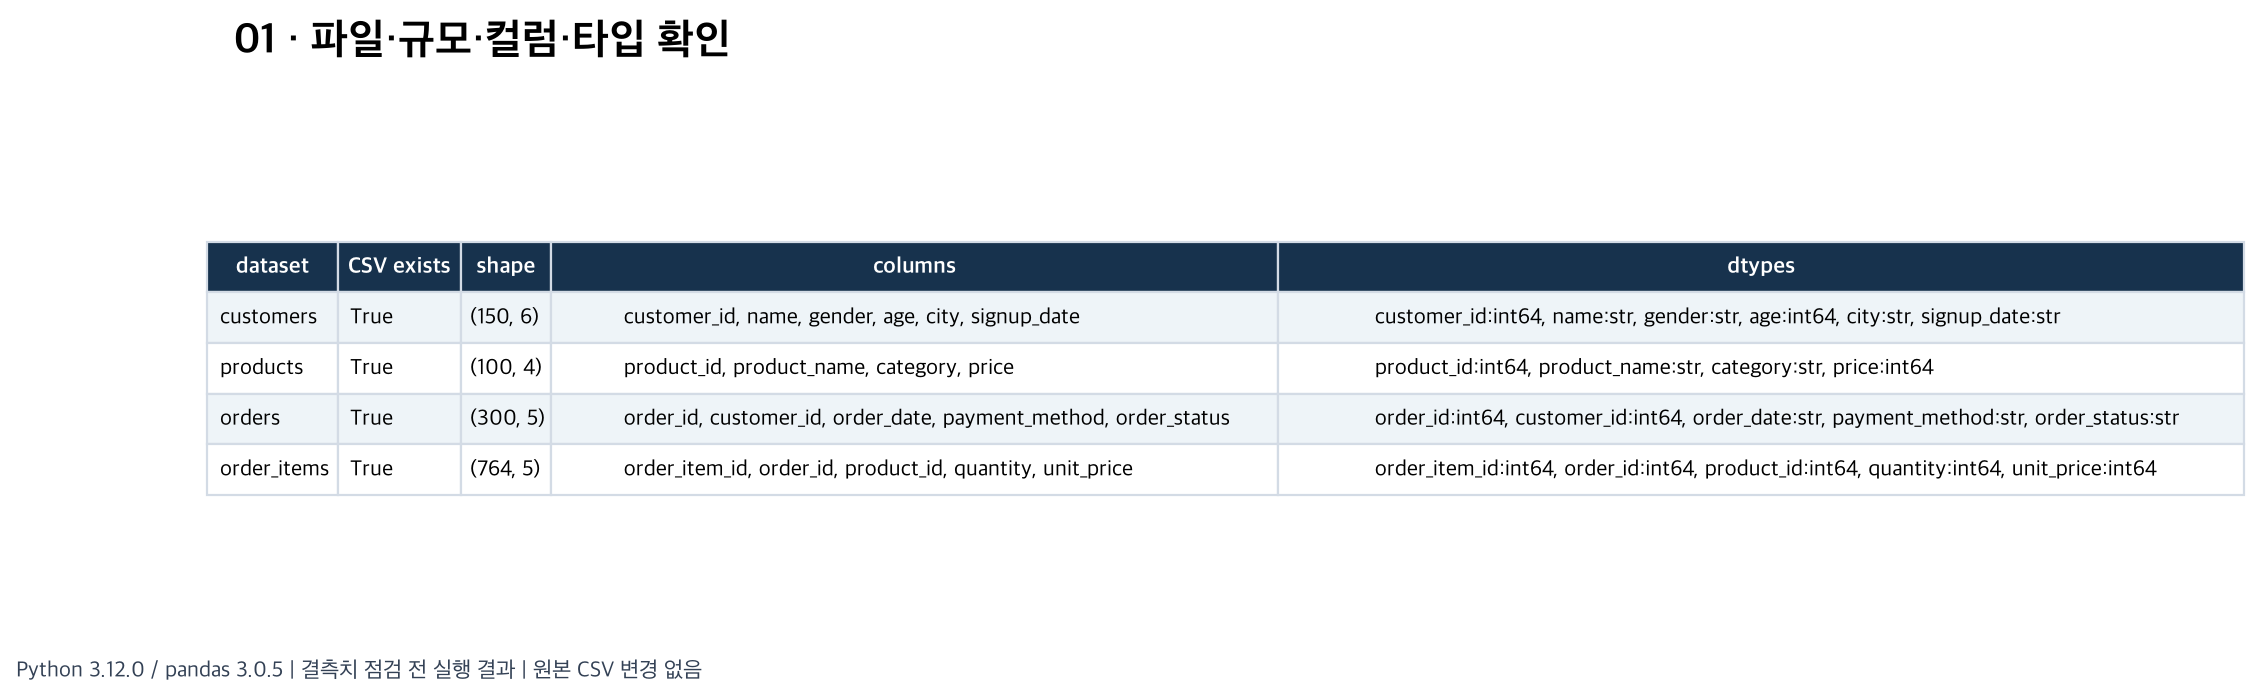

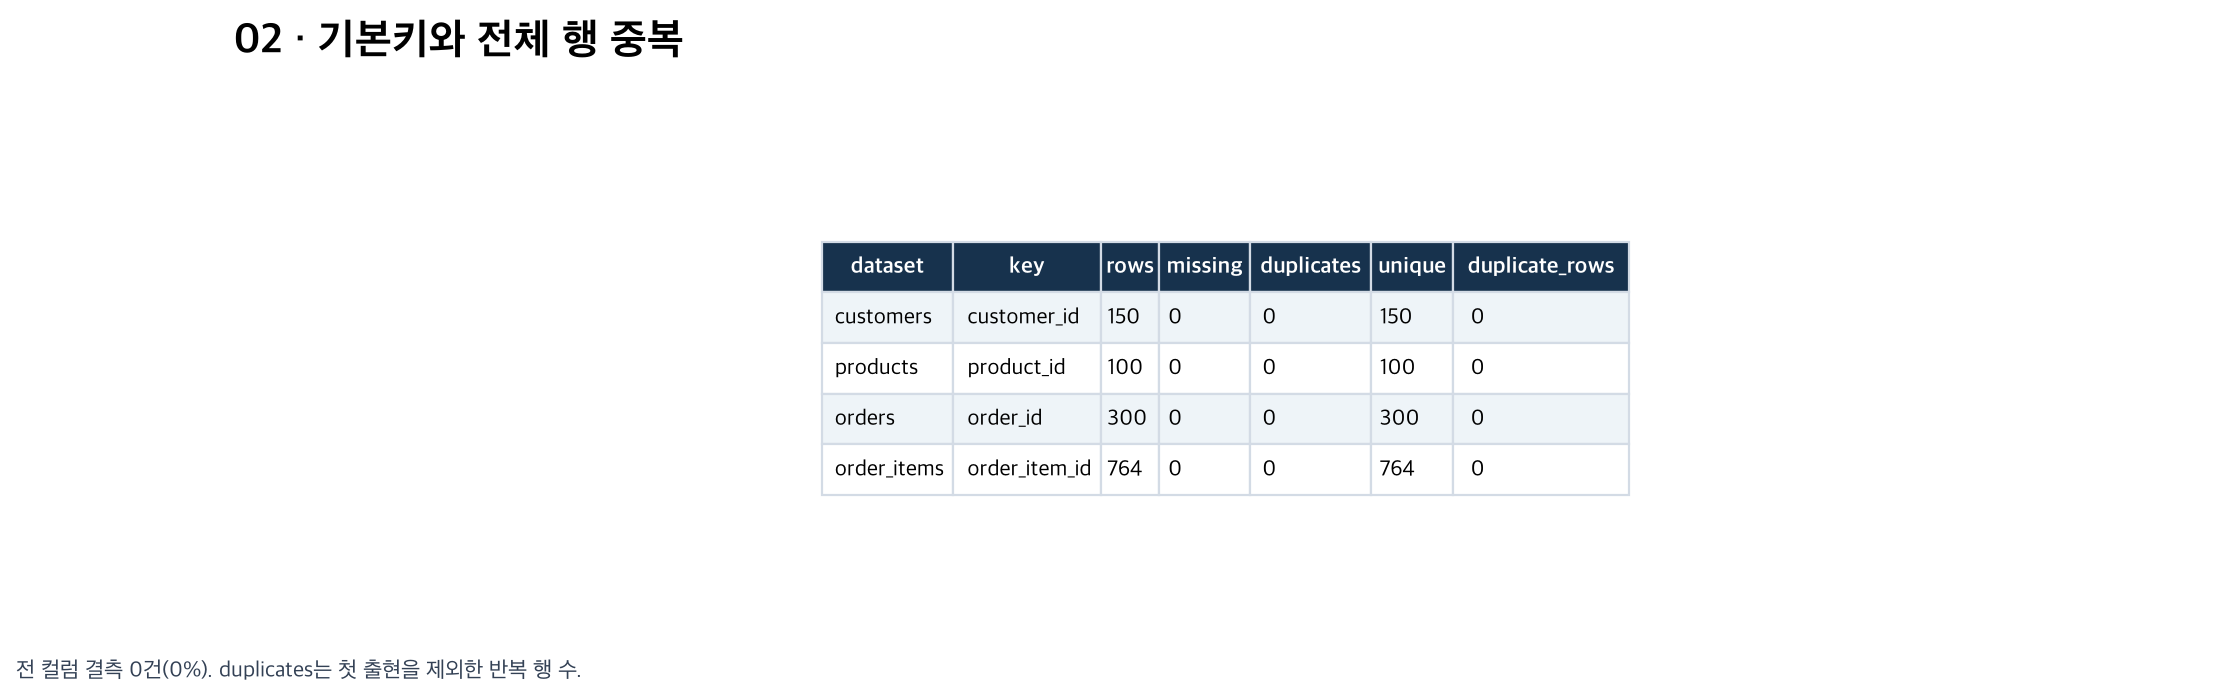

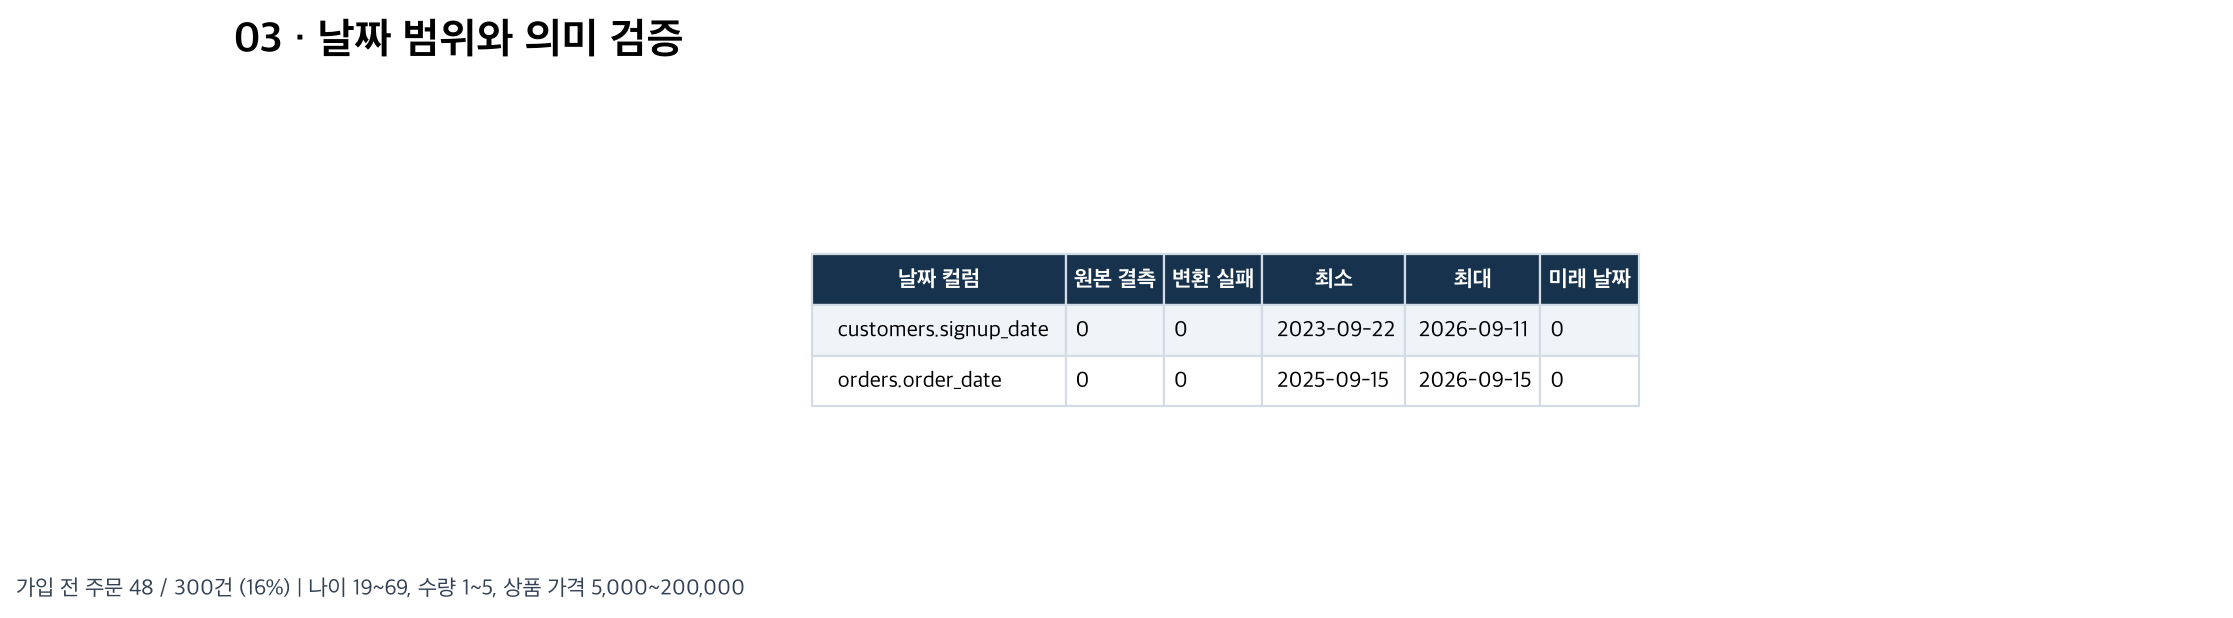

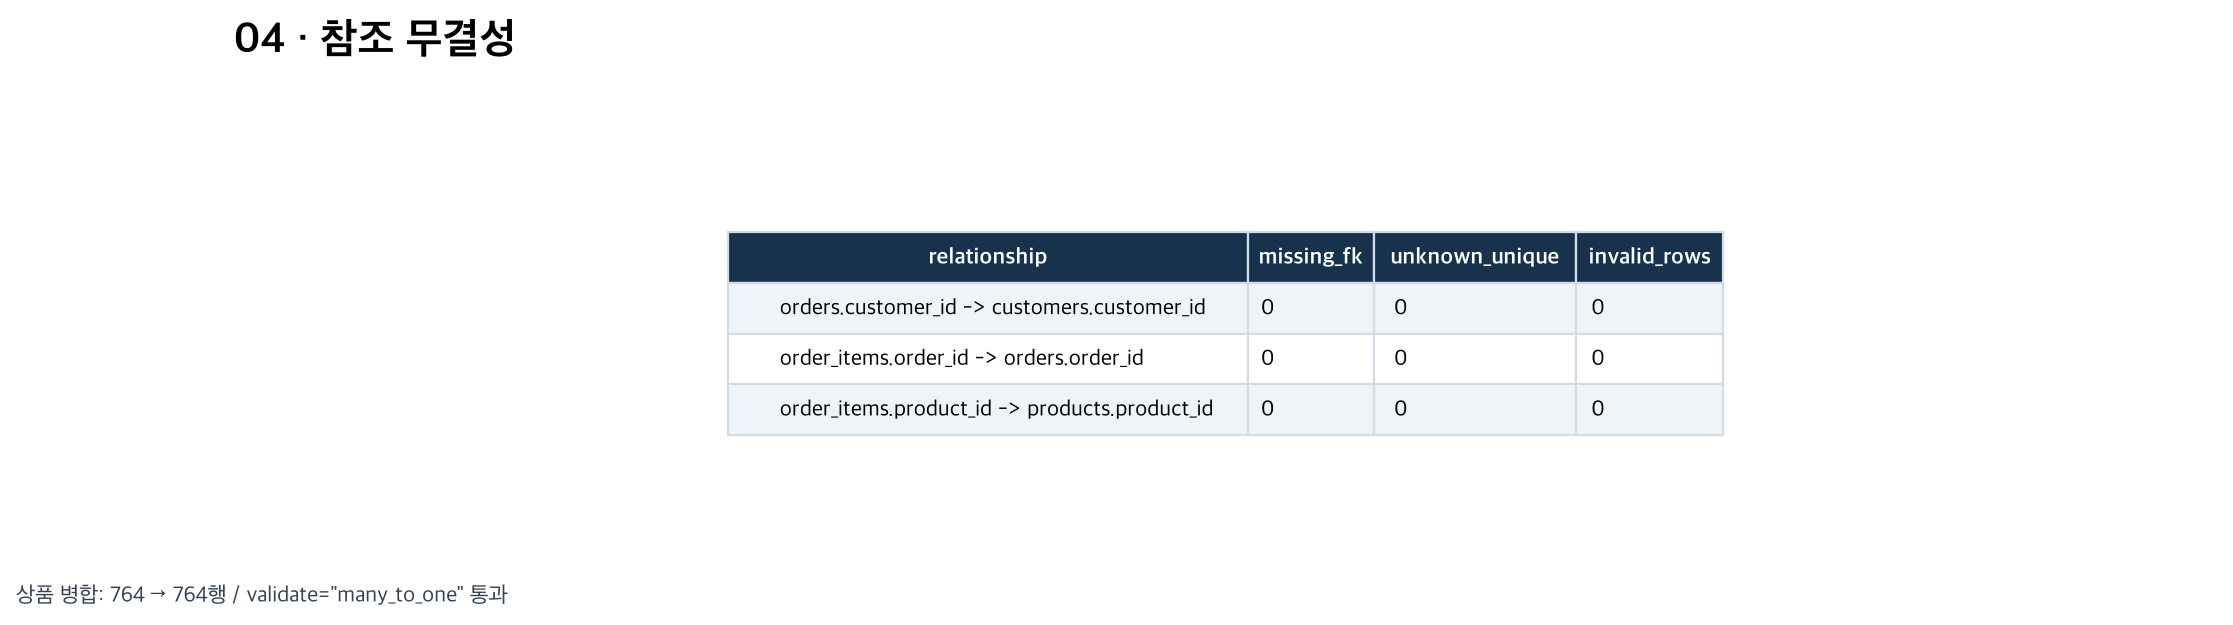

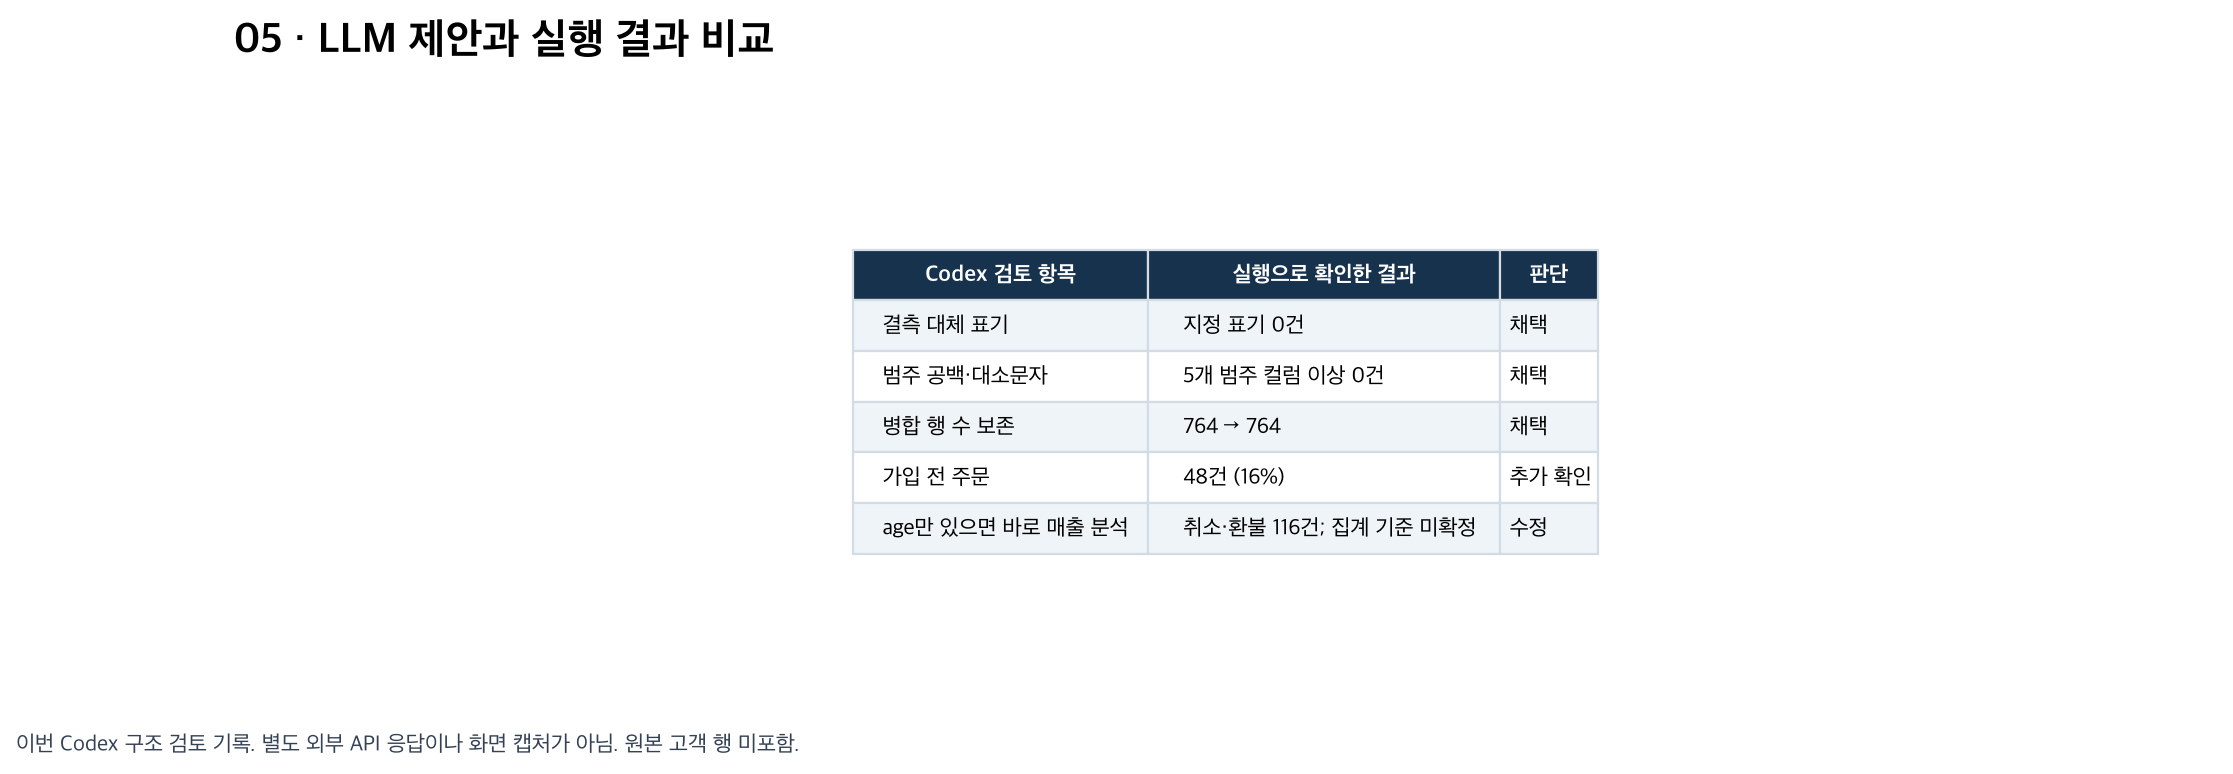

원본 DataFrame 보존: PASS


In [44]:

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from matplotlib import font_manager
from IPython.display import Image
font_path=Path('/System/Library/Fonts/AppleSDGothicNeo.ttc')
if font_path.exists():
 font_manager.fontManager.addfont(str(font_path))
 plt.rcParams['font.family']=font_manager.FontProperties(fname=str(font_path)).get_name()
plt.rcParams['axes.unicode_minus']=False

def save_evidence(filename,title,frame,note):
 fig,ax=plt.subplots(figsize=(16,max(3.6,0.55*len(frame)+2)))
 ax.axis('off'); fig.patch.set_facecolor('white')
 ax.set_title(title,loc='left',fontsize=19,fontweight='bold',pad=25)
 table=ax.table(cellText=frame.astype(str).values,colLabels=frame.columns,loc='center',cellLoc='left')
 table.auto_set_font_size(False);table.set_fontsize(10);table.scale(1,1.9)
 table.auto_set_column_width(col=list(range(len(frame.columns))))
 for (row,col),cell in table.get_celld().items():
  cell.set_edgecolor('#d3dbe5')
  if row==0:cell.set_facecolor('#17324d');cell.set_text_props(color='white',weight='bold')
  elif row%2:cell.set_facecolor('#eef4f8')
 fig.text(0.04,0.035,note,fontsize=10,color='#334155')
 fig.savefig(OUT/'images'/filename,dpi=160,bbox_inches='tight');plt.close(fig)
 display(Image(filename=str(OUT/'images'/filename)))

save_evidence('step01_structure.png','01 · 데이터 구조 — 실제 실행 결과',shape_summary.assign(primary_key=list(primary_keys.values())),f'Python {sys.version.split()[0]} / pandas {pd.__version__} | 날짜 원본 dtype: {orders.order_date.dtype} | 원본 CSV 변경 없음')
save_evidence('step02_quality.png','02 · 기본키와 전체 행 중복',quality,'전 컬럼 결측 0건(0%). duplicates는 첫 출현을 제외한 반복 행 수.')
evidence_dates=date_summary.rename(columns={'column':'날짜 컬럼','original_missing':'원본 결측','conversion_failures':'변환 실패','min':'최소','max':'최대','future':'미래 날짜'})
save_evidence('step03_distribution.png','03 · 날짜 범위와 의미 검증',evidence_dates,f'가입 전 주문 {chronology_count} / {len(orders)}건 ({chronology_count/len(orders):.0%}) | 나이 19~69, 수량 1~5, 상품 가격 5,000~200,000')
save_evidence('step04_relationship.png','04 · 참조 무결성',relations_summary.drop(columns=['unknown_ids']),f'상품 병합: {len(order_items)} → {len(order_items_with_products)}행 / validate="many_to_one" 통과')
llm_evidence=pd.DataFrame([
 ['결측 대체 표기','지정 표기 0건','채택'],['범주 공백·대소문자','5개 범주 컬럼 이상 0건','채택'],['병합 행 수 보존',f'{len(order_items)} → {len(order_items_with_products)}','채택'],['가입 전 주문',f'{chronology_count}건 (16%)','추가 확인'],['age만 있으면 바로 매출 분석','취소·환불 116건; 집계 기준 미확정','수정']],columns=['Codex 검토 항목','실행으로 확인한 결과','판단'])
save_evidence('step05_llm.png','05 · LLM 제안과 실행 결과 비교',llm_evidence,'이번 Codex 구조 검토 기록. 별도 외부 API 응답이나 화면 캡처가 아님. 원본 고객 행 미포함.')
# CSV 내용 및 메모리 원본 보존 검증
for name,df in datasets.items():
 pd.testing.assert_frame_equal(df,pd.read_csv(DATA_DIR/f'{name}.csv'))
print('원본 DataFrame 보존: PASS')


# Chapter 03 제출 답안. 데이터의 첫인상 읽기

> 주 제출물: `chapter03/chapter03.ipynb`. 이 문서의 답안은 Notebook의 Markdown 셀에도 포함했다. 증빙 이미지는 Notebook의 실제 실행 결과를 표로 렌더링한 자료다.

## 0. 제출 정보

- 이름: 송누리
- GitHub ID: HauserNR
- 작성일: 2026-09-23
- 최종 제출 URL(업로드 후 사용할 경로): https://github.com/HauserNR/llm-data-analysis-study/blob/main/chapter03/chapter03.ipynb
- 작성 기준: 첨부 과제 안내, `chapter03.md` 양식, 제공된 `notebooks/ch03_data_overview.ipynb`, 기존 CSV 4개.
- 실행 환경: Python 3.12.0, pandas 3.0.5, 프로젝트 `.venv`의 Jupyter 커널.
- 실행 방법: 저장소 루트 또는 `chapter03`에서 해당 커널을 선택하고 Restart Kernel → Run All.
- AI 활용: Codex가 코드 보완, 구조 요약 검토, 실행 및 답안 초안 작성을 도왔다. 아래 LLM 검토는 이번 Codex 작업의 검토 기록이며 별도 외부 API 호출 기록을 뜻하지 않는다.
- 확인 범위: [eTL 과제 안내](https://myetl.snu.ac.kr/courses/310975/assignments/378788)를 로그인 후 직접 확인했다. 실행 완료 Notebook, Notebook 내 Markdown 답안, 증빙 4~5장 및 최종 Notebook 파일 URL 제출 조건을 반영했다. 별도 Markdown은 검토용 사본이며 LMS의 기본 제출물은 Notebook이다. GitHub 업로드 및 eTL 제출은 아직 수행하지 않았다.

## 1. 데이터 로딩과 구조 확인

### 실행/결과

- **4개 CSV 로딩 여부:** `customers.csv`, `products.csv`, `orders.csv`, `order_items.csv`가 모두 존재했고, `pd.read_csv()`로 DataFrame에 로딩했다. 파일 존재 확인 결과도 네 개 모두 `True`였다.
- **각 데이터 shape:** `customers` (150, 6), `products` (100, 4), `orders` (300, 5), `order_items` (764, 5).
- **주요 컬럼:**
  - `customers`: `customer_id`, `name`, `gender`, `age`, `city`, `signup_date` (고객 한 명당 한 행).
  - `products`: `product_id`, `product_name`, `category`, `price` (상품 하나당 한 행).
  - `orders`: `order_id`, `customer_id`, `order_date`, `payment_method`, `order_status` (주문 한 건당 한 행).
  - `order_items`: `order_item_id`, `order_id`, `product_id`, `quantity`, `unit_price` (주문 상품 항목 한 개당 한 행).
- **dtypes에서 주목한 컬럼:** `customers.signup_date`와 `orders.order_date`는 날짜처럼 보이지만 로딩 직후 `str`이다. `age`, `price`, `quantity`, `unit_price`는 `int64`이며 각 ID도 `int64`다. ID는 숫자로 저장돼도 식별자이므로 평균의 의미가 없다. 현재 환경(pandas 3.0.5)에서는 문자열 컬럼이 `str`로 표시된다.

### Evidence

![데이터 구조 확인](images/step01_structure.png)

기존 Notebook의 `for name, df in datasets.items(): df.info()` 실행 결과 한 화면만 캡처한다. 이 출력에는 네 데이터셋의 행 수, 컬럼명, 결측이 아닌 값의 수, dtype이 함께 표시되어 1번 항목의 핵심 Evidence로 적합하다.

### 결과 관찰

네 파일 모두 열렸고 행 수는 `order_items` 764행이 가장 많다. `orders`는 300행이므로 주문상세 행 수가 주문 행 수보다 많다. 고객·주문 날짜 컬럼은 로딩 직후 문자열이고, 숫자처럼 저장된 ID 컬럼이 각 파일에 존재한다. `head()`/`tail()` 표본의 한글과 날짜 문자열은 읽을 수 있었으며 고객 이름은 출력에서 마스킹했다.

### 나의 해석과 판단

분석 전에 `orders`와 `order_items`의 **행 단위 차이**에 주의해야 한다. 주문상세 764행을 주문 764건으로 해석하면 주문 수를 과대 계산한다. `signup_date`와 `order_date`는 날짜 계산 전에 변환 가능 여부를 확인해야 한다. `order_status`는 이후 금액을 집계할 때 포함할 주문 범위를 정하는 데 중요하다.

### 업무·분석적 의미

한 행이 고객·상품·주문·주문 상품 항목 중 무엇을 나타내는지 확인하지 않으면 병합 후 건수나 금액이 부풀 수 있다. 문자열 날짜로 기간 분석을 시도하면 계산이 잘못되거나 실패할 수 있다. 식별자인 ID를 일반 숫자처럼 평균 내면 업무 의미가 없는 결과가 나온다.

### 한계와 추가 확인 사항

이 단계의 `shape`, `head()`, `tail()`, `columns`, `dtypes`, `info()`만으로는 **결측치, 전체 행·ID 중복, 숫자 범위, 날짜 변환 실패, 참조 무결성**을 알 수 없다. 표본 밖의 값이 정상인지도 단정할 수 없어 다음 절에서 별도로 점검한다.

## 2. 결측·중복·키 품질

### 실행/결과

| 데이터셋 | 주요 ID | ID 결측 | ID 중복(첫 행 제외) | 고유 ID 수 | 전체 행 중복 |
|---|---|---:|---:|---:|---:|
| customers | customer_id | 0 | 0 | 150 | 0 |
| products | product_id | 0 | 0 | 100 | 0 |
| orders | order_id | 0 | 0 | 300 | 0 |
| order_items | order_item_id | 0 | 0 | 764 | 0 |

전 컬럼의 `isna()` 결측 개수는 0건, 결측 비율은 0%다. 문자열의 빈 값·`-`·`unknown`·`n/a`·`null`·`none` 대체 표기도 공백 제거와 소문자화 후 점검했으며 0건이다.

![결측 중복 점검](images/step02_quality.png)

### 결과 관찰

기본키 네 개는 모두 결측 없이 고유하다. 반면 `orders.customer_id`는 174건, `order_items.order_id`는 464건, `order_items.product_id`는 664건의 반복이 있다. 여기서 건수는 `duplicated()`가 첫 출현을 제외하고 센 행 수이며, 반복 ID의 종류 수가 아니다.

### 나의 해석과 판단

외래 키 반복은 고객의 여러 주문이나 주문의 여러 항목을 나타낼 수 있으므로 삭제 근거가 아니다. 실제 기본 결측·중복 문제는 없으므로 임의의 정제는 하지 않는다. 이후 문제가 발생하면 조인에 영향을 주는 기본키 결측·중복과 참조 불일치를 우선 확인하고, 일반 속성 결측은 업무적 의미를 확인한다.

### 업무·분석적 의미

주문상세에서 order_id 기준으로 중복을 삭제하면 정상 항목과 주문 금액이 사라진다. 반대로 부모 키 중복을 놓치면 병합 결과가 늘어나 금액이 부풀 수 있다.

### 한계와 추가 확인 사항

현재 점검은 기술적 결측과 지정한 대체 표기에 한정된다. 값이 채워져 있어도 잘못 입력된 나이·날짜일 수 있으며, 다른 코드로 표현된 미상값이 없는지는 데이터 사전과 비교해야 한다.

## 3. 숫자형·범주형·날짜 점검

### 실행/결과

| 컬럼 | 최솟값 | 최댓값 | 평균 | 중앙값 |
|---|---:|---:|---:|---:|
| customers.age | 19 | 69 | 42.09 | 40 |
| products.price | 5,000 | 200,000 | 110,040 | 112,000 |
| order_items.quantity | 1 | 5 | 3.05 | 3 |
| order_items.unit_price | 5,000 | 200,000 | 108,561.52 | 111,000 |

가격·수량·단가의 0 이하 값은 모두 0건이다. 나이 범위는 19~69세로 관측되지만 업무상 허용 연령은 별도 확인 대상이다.

- 성별: F 84명, M 66명.
- 도시: 성남 21, 광주 17, 부산 16, 대구 15, 서울 15, 울산 14, 인천 14, 대전 14, 수원 13, 고양 11명.
- 카테고리: 스포츠 19, 전자기기 17, 생활용품 16, 뷰티 16, 도서 14, 패션 11, 식품 7개. 이 빈도는 상품 수이지 판매 수량이 아니다.
- 결제수단: kakao_pay 79, naver_pay 77, bank_transfer 74, card 70건.
- 주문상태: completed 184건(61.33%), cancelled 64건(21.33%), refunded 52건(17.33%).
- 위 범주 컬럼의 앞뒤 공백과 공백 제거·대소문자 통일 시 합쳐지는 표기 변형은 0건이다. 의미상 동의어 전체를 검사한 것은 아니다.

| 날짜 컬럼 | 기존 결측 | 새 변환 실패 | 최솟값 | 최댓값 | 2026-09-23 이후 |
|---|---:|---:|---|---|---:|
| customers.signup_date | 0 | 0 | 2023-09-22 | 2026-09-11 | 0 |
| orders.order_date | 0 | 0 | 2025-09-15 | 2026-09-15 | 0 |

원본 문자열을 유지한 채 별도 Series로 변환했다. 새로운 변환 실패는 `원본.notna() & 변환값.isna()`로 계산해 기존 결측과 구분했다.

![기본 분포와 날짜 확인](images/step03_distribution.png)

### 결과 관찰

날짜 형식 변환은 전부 성공했지만, 고객 키로 연결해 비교한 결과 **가입일보다 주문일이 빠른 주문이 48건, 전체 300건의 16%**다. 따라서 변환 성공과 업무적 타당성은 다르다. 주문 기간은 약 1년이지만 시작·종료 월인 9월은 각각 일부 날짜만 포함한다.

### 나의 해석과 판단

48건은 회원 가입 후에만 주문할 수 있는 시스템이라면 이상 후보지만, 비회원 주문·계정 이관 등 정책에 따라 설명될 가능성도 있다. 가상 데이터 생성 코드는 가입일과 주문일을 별도로 생성하므로 날짜 순서를 보장하지 않는다는 점도 확인했다. 이를 근거로 운영 시스템의 오류라고 단정하거나 날짜를 임의 수정하지 않는다.

### 업무·분석적 의미

가입 전 주문이 있으면 가입 후 첫 구매 소요일이나 코호트 분석이 왜곡된다. 월별 비교에서는 관측 기간이 완전한 월인지 확인해야 한다. 취소·환불 116건을 모두 매출로 포함하면 확정 매출과 다른 수치가 된다.

### 한계와 추가 확인 사항

허용 날짜 범위, 비회원 구매 정책, 통화 단위, 할인·부분 환불·세금 정의가 필요하다. `completed`만 선택하더라도 실제 정산 금액을 완전히 재현한다고 단정할 수 없다.

## 4. CSV 간 키 관계 검증

### 실행/결과

| 자식 → 부모 | 없는 ID 목록 | 없는 ID 종류 수 | 영향을 받는 행 | 외래 키 결측 |
|---|---|---:|---:|---:|
| orders.customer_id → customers.customer_id | [] | 0 | 0 | 0 |
| order_items.order_id → orders.order_id | [] | 0 | 0 | 0 |
| order_items.product_id → products.product_id | [] | 0 | 0 | 0 |

![PK FK 관계 검증](images/step04_relationship.png)

### 결과 관찰

세 관계 모두 참조 무결성 점검을 통과했다. `order_items`와 `products`를 `validate="many_to_one"`으로 병합했으며 행 수는 764 → 764로 유지됐다. 각 주문에는 1~4개 상세가 있다. 관측 기간에 주문이 없는 고객은 24명이다.

### 나의 해석과 판단

부모 ID의 고유성과 자식 ID의 참조 존재를 함께 확인했으므로 기본적인 다대일 연결은 가능하다. 주문 없는 고객은 비활성·신규 고객일 수 있어 오류로 삭제하지 않는다. 없는 키가 발견되더라도 파일 추출 시점 차이, 부모 파일 누락, 이관 등을 확인하기 전에 삭제하면 복구 가능한 거래가 사라질 수 있다.

### 업무·분석적 의미

참조 검증과 병합 행 수 확인은 조인으로 인한 누락·중복 계산을 예방한다. 제공 노트북의 병합 실습에서 계산한 카테고리별 금액은 모든 상태의 `quantity × unit_price` 합계다.

| 카테고리 | 전체 상태 포함 주문상세 금액(원본 단위) |
|---|---:|
| 스포츠 | 50,174,000 |
| 뷰티 | 47,551,000 |
| 전자기기 | 41,003,000 |
| 생활용품 | 34,839,000 |
| 식품 | 33,597,000 |
| 도서 | 24,645,000 |
| 패션 | 23,801,000 |

### 한계와 추가 확인 사항

키가 존재한다고 거래 의미까지 맞는 것은 아니다. 가입 전 주문 48건이 그 예다. 위 합계는 취소·환불·할인·세금을 반영한 순매출이나 카테고리 성과 결론이 아니다.

## 5. LLM 구조 설명 검증

### LLM에 제공한 Safe Context

이번 Codex 검토에는 데이터셋 크기, 실제 컬럼과 dtype, 결측 개수·비율, 주요 ID 결측·중복, 전체 중복, 범주 빈도, 날짜 범위, 참조 무결성의 집계 결과를 사용했다. 재사용 가능한 전체 구조 요약은 `safe_context.json` 및 Notebook 실행 출력에 저장했다. 고객 이름·원본 고객 행·API 키는 포함하지 않았다.

다음 질문으로 구조 검토 범위를 명시했다.

> 온라인 쇼핑몰 CSV 4개의 안전한 구조 요약을 검토해 주세요. 각 데이터셋의 한 행 의미, 기본키와 외래 키를 구분하고, 즉시 삭제하면 안 되는 사례와 추가 점검 우선순위를 설명해 주세요. 실제 컬럼에 없는 정보는 가정하지 말고 각 제안에 대해 pandas로 무엇을 확인할지 설명해 주세요. 원본 행 대신 safe_schema_summary를 사용합니다.

### LLM이 제안한 추가 점검과 실제 검증

| Codex 구조 검토 제안·설명 | 실제 확인 결과 | 판단 |
|---|---|---|
| 기본키 고유성과 외래 키 반복을 구분 | 네 PK 결측·중복 0; 주문상세 order_id 반복 464 | 채택. 외래 키 반복 삭제 안 함 |
| isna 외에 결측 대체 표기 확인 | 지정한 대체 표기 0건 | 채택. 다른 코드 여부는 보류 |
| 범주 공백·대소문자 차이 확인 | 다섯 범주 컬럼에서 공백·정규화 충돌 0건 | 채택. 의미상 동의어는 별도 확인 |
| 병합 관계 및 행 수 보존 확인 | many_to_one 검증 통과, 764 → 764 | 채택 |
| 변환 성공과 날짜 선후관계 구분 | 가입 전 주문 48건(16%) | 채택. 원인과 처리 기준은 보류 |
| age가 있으니 연령별 매출을 바로 계산할 수 있다는 제공 노트북의 가정 예시 | age 존재·결측 0, 키 연결 가능; 취소·환불 116건 및 날짜 문제 존재 | 수정. 컬럼 존재만으로 분석 준비 완료 판단 불가 |

![LLM 구조 검토](images/step05_llm.png)

### 결과 관찰

기본키·참조 관계 및 지정한 결측 대체 표기는 점검을 통과했다. 추가 날짜 비교에서는 가입 전 주문 48건을 확인했고, 주문상태에는 취소·환불 116건이 포함되어 있었다. 이는 실행 결과로 확인한 사실이며 원인에 대한 확정은 아니다.

### 업무·분석적 의미

LLM 제안을 실행 가능한 점검 항목으로 바꾸고 결과를 대조하면, 잘못된 중복 삭제나 매출 과대 집계를 예방할 수 있다. 채택·수정·보류를 남기면 다음 분석 단계에서 확인된 사실과 미확정 업무 규칙을 구분할 수 있다.

### 나의 해석과 판단

가장 유용한 제안은 날짜 형식과 업무적 선후관계를 나눠 확인한 것이다. 기본 점검을 통과해도 가입 전 주문 48건이 남았다. 가장 조심할 것은 ID의 반복을 오류로 단정하거나 age 컬럼이 있다는 이유만으로 매출 분석을 바로 권하는 설명이다. 실제 컬럼과 키 관계에 맞는 제안만 채택했다.

### 한계와 추가 확인 사항

LLM 검토는 업무 규칙의 확인을 대신하지 못한다. 별도의 API 응답을 받은 것처럼 기록하지 않았으며, 대화의 구조 검토 내용을 코드 실행 결과와 비교해 정리했다. 원본 고객 행의 추가 제공 없이 정책·데이터 사전으로 미확정 항목을 확인해야 한다.

## 6. Chapter 03 최종 판단

### 데이터의 첫인상 3가지

1. 고객 150명, 상품 100개, 주문 300건, 상세 764행의 관계형 실습 데이터다. 기본 결측·전체 중복·PK 중복·없는 참조 키는 발견되지 않았다.
2. 데이터 타입과 의미는 다르다. ID는 측정값이 아니고 날짜는 문자열이며, 변환 성공 후에도 가입 전 주문 48건이 남는다.
3. 완료·취소·환불 상태가 섞여 있다. 연결 가능한 데이터라는 사실과 매출 분석 기준이 확정됐다는 것은 별개다.

### 다음 Chapter 전에 반드시 확인/처리해야 할 항목

1. 가입 전 주문 48건을 품질 이슈로 기록하고, 비회원 주문 여부 및 합성 데이터 생성 규칙을 확인한다. 날짜 의존 분석은 기준 확정 전 유보한다.
2. 주문 수·주문상세 수·전체 주문 금액·확정 매출의 정의를 구분하고 취소·환불, 금액 단위, 분석 기간 기준을 정한다.
3. 날짜 변환과 키 검증을 재현 가능한 코드로 유지한다. 삭제·대체·날짜 수정은 이번 장에서 하지 않고 Chapter 05에서 업무 규칙에 따라 결정한다.

### 현재 데이터만으로 단정할 수 없는 것

실제 사업의 매출·고객 특성·카테고리 성과, 가입 전 주문의 업무적 오류 여부, 정확한 통화와 정산 금액, 데이터 누락 여부 및 실거래 대표성은 확정할 수 없다.

### 데이터 품질 발견 기록

| 데이터셋·컬럼 | 문제/주의 종류 | 건수 | 해석 | 처리 여부 |
|---|---|---:|---|---|
| orders.order_date ↔ customers.signup_date | 가입 전 주문 | 48주문 | 시간 의미 검증 필요 | 기록, Chapter 05에서 결정 |
| orders.order_status | cancelled / refunded | 64 / 52주문 | 집계 기준 필요; 자체가 오류는 아님 | 유지 |
| order_items.order_id | FK 반복(첫 출현 제외) | 464행 | 한 주문의 여러 상세 가능 | 유지 |
| customers.customer_id | 주문 없는 고객 | 24명 | 관측 기간 내 구매 없음 | 유지 |

## 부록. 자습 과제

### 과제 1. 네 파일 데이터 사전

| 데이터셋 | 한 행 | PK | FK | 측정 숫자형 | 범주형 | 날짜 후보(원본 str) |
|---|---|---|---|---|---|---|
| customers | 고객 | customer_id | 없음 | age | gender, city | signup_date |
| products | 상품 | product_id | 없음 | price | category | 없음 |
| orders | 주문 | order_id | customer_id | 없음 | payment_method, order_status | order_date |
| order_items | 주문 상품 항목 | order_item_id | order_id, product_id | quantity, unit_price | 없음 | 없음 |

`name`과 `product_name`은 이름을 나타내는 문자열 속성이다. ID는 int64로 저장되지만 측정 숫자형 항목에서 제외했다.

### 과제 2. 발견과 처리 구분하기 — 가정 사례

아래 수치는 실제 데이터에서 발견한 결과가 아니라 과제에서 제시한 가정이다.

| 가정 문제 | 위험 수준 | 추가 확인 | 이번 장에서 할 일 | 전처리 장에서 결정 |
|---|---|---|---|---|
| 고객 나이 5건 결측 | 중간 | 선택 입력인지, 특정 집단에 편중됐는지 | 건수·비율 및 분포 기록 | 분석별 제외/대체 여부 |
| 고객 ID 1건 중복 | 높음 | 동일 고객 재적재인지, 속성 충돌인지 | 중복 행과 키 단위 기록 | 병합/대표행/원천 수정 |
| Complete와 completed 혼재 | 중간 | 실제 같은 상태인지 | 원본 값과 빈도 기록 | 공식 매핑 후 표준화 |
| 상세의 주문 ID 2건이 부모에 없음 | 높음 | 추출 시점·기간·부모 누락 여부 | ID 종류 수와 영향 행 수 분리 | 부모 복구/격리/제외 기준 |

### 과제 3. 데이터 타입 오류 사례

`["1000", "2,000", "unknown", None, " 3500 "]`의 원본 dtype은 `str`이다. 쉼표와 공백을 제거하고 `pd.to_numeric(errors="coerce")`를 실행하면 `[1000.0, 2000.0, NaN, NaN, 3500.0]`이 된다. 기존 결측 1건, 변환 후 결측 2건, 새 변환 실패는 `unknown` 1건이다. `None`까지 변환 실패로 세지 않는다. 원본·정리값·변환값 비교표는 Notebook에 포함했다.

### 과제 4. 안전한 LLM 구조 질문

5절의 질문과 `safe_context.json`을 사용한다. 집계 및 구조 정보만 전달하고 실제 데이터에 없는 컬럼과 관계를 가정하지 않도록 요청한다.

## 최종 제출 체크

- [x] Notebook을 처음부터 끝까지 실행했습니다.
- [x] 오류 셀이 남아 있지 않습니다.
- [x] 핵심 Evidence를 첨부했습니다.
- [x] 관찰과 해석을 구분했습니다.
- [x] 원본 고객 이름을 마스킹하고 Secret을 포함하지 않았습니다(제출자 이름·GitHub ID는 제출 정보에 기재).
- [ ] `chapter03/chapter03.ipynb`가 GitHub에서 정상 표시됩니다. — 업로드 후 확인 필요.
- [ ] 최종 Notebook 파일 URL을 제출합니다. — eTL 제출 전.